In [10]:
# If running in Colab, uncomment:
# !pip install tensorflow scikit-learn

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.model_selection import train_test_split

import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [11]:
DATASET_PATH = "utkface_aligned_cropped/crop_part1"   # change path if needed

IMAGE_SIZE = 224
BATCH_SIZE = 8
MAX_SAMPLES = None

In [12]:
def parse_filename(filename):
    """
    Parse UTKFace filename: age_gender_race_date.jpg
    Keep only teenagers (13-19)
    """
    base = os.path.basename(filename)
    parts = base.split("_")

    if len(parts) < 2:
        raise ValueError("Invalid filename")

    age = int(parts[0])
    gender = int(parts[1])

    # keep only teenagers
    if age < 13 or age > 19:
        raise ValueError("Not a teenager")

    return age, gender

In [13]:
def build_dataset(file_paths, image_size, batch_size,
                  shuffle=True, augment=False, balance_classes=False):

    ages = []
    genders = []
    valid_paths = []

    for p in file_paths:
        try:
            age, gender = parse_filename(p)
            ages.append(age)
            genders.append(gender)
            valid_paths.append(p)
        except:
            continue

    ages = np.array(ages, dtype=np.float32)
    genders = np.array(genders, dtype=np.int32)
    valid_paths = np.array(valid_paths)

    # Balance genders
    if balance_classes:
        male_idx = np.where(genders == 0)[0]
        female_idx = np.where(genders == 1)[0]

        n = min(len(male_idx), len(female_idx))

        balanced_idx = np.concatenate([
            np.random.choice(male_idx, n, replace=False),
            np.random.choice(female_idx, n, replace=False)
        ])

        np.random.shuffle(balanced_idx)

        valid_paths = valid_paths[balanced_idx]
        ages = ages[balanced_idx]
        genders = genders[balanced_idx]

    # normalize age (13-19 → 0-1)
    ages_norm = (ages - 13) / 6.0

    ds = tf.data.Dataset.from_tensor_slices((valid_paths, genders, ages_norm))

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(valid_paths), 2048))

    def load_image(path, gender, age):

        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [image_size, image_size])

        if augment:

            img = tf.image.random_flip_left_right(img)

            if tf.random.uniform([]) > 0.2:
                crop = tf.random.uniform([], 0.75, 0.98)
                h = tf.cast(image_size * crop, tf.int32)
                w = tf.cast(image_size * crop, tf.int32)

                img = tf.image.random_crop(img, [h, w, 3])
                img = tf.image.resize(img, [image_size, image_size])

            img = tf.image.random_brightness(img, 0.25)
            img = tf.image.random_contrast(img, 0.8, 1.2)
            img = tf.image.random_saturation(img, 0.8, 1.2)
            img = tf.image.random_hue(img, 0.12)

            img = tf.clip_by_value(img, 0.0, 255.0)

        img = preprocess_input(img)

        return img, {"gender": gender, "age": age}

    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return ds, ages

In [14]:
all_files = [
    os.path.join(DATASET_PATH, f)
    for f in os.listdir(DATASET_PATH)
    if f.lower().endswith(".jpg")
]

if MAX_SAMPLES:
    all_files = all_files[:MAX_SAMPLES]

print("Total Images:", len(all_files))

train_paths, val_paths = train_test_split(
    all_files,
    test_size=0.15,
    random_state=42
)

train_ds, _ = build_dataset(
    train_paths,
    IMAGE_SIZE,
    BATCH_SIZE,
    shuffle=True,
    augment=True,
    balance_classes=True
)

val_ds, _ = build_dataset(
    val_paths,
    IMAGE_SIZE,
    BATCH_SIZE,
    shuffle=False
)

print("Dataset Ready")

Total Images: 9780
Dataset Ready


In [15]:
def create_model(image_size):

    base_model = MobileNetV2(
        input_shape=(image_size, image_size, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    inputs = base_model.input
    x = base_model.output

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(512, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    gender_output = layers.Dense(2, activation="softmax", name="gender")(x)
    age_output = layers.Dense(1, activation="linear", name="age")(x)

    model = Model(inputs, [gender_output, age_output])

    return model, base_model


model, base_model = create_model(IMAGE_SIZE)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,095,235 (11.81 MB)

 Trainable params: 832,899 (3.18 MB)

 Non-trainable params: 2,262,336 (8.63 MB)

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1.5e-3),
    loss={
        "gender": tf.keras.losses.SparseCategoricalCrossentropy(),
        "age": tf.keras.losses.MeanSquaredError()
    },
    loss_weights={
        "gender": 2.0,
        "age": 0.5
    },
    metrics={
        "gender": ["accuracy"],
        "age": ["mae"]
    }
)

In [17]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_gender_accuracy",
            patience=8,
            restore_best_weights=True,
            mode='max'
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_gender_accuracy",
            factor=0.5,
            patience=4,
            mode='max'
        )
    ]
)

Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - age_loss: 1.3463 - age_mae: 0.8955 - gender_accuracy: 0.5615 - gender_loss: 0.7728 - loss: 2.2345 - val_age_loss: 0.1489 - val_age_mae: 0.3111 - val_gender_accuracy: 0.7292 - val_gender_loss: 0.5565 - val_loss: 1.1875 - learning_rate: 0.0015
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - age_loss: 0.6433 - age_mae: 0.6437 - gender_accuracy: 0.6845 - gender_loss: 0.6331 - loss: 1.5881 - val_age_loss: 0.1639 - val_age_mae: 0.3243 - val_gender_accuracy: 0.7569 - val_gender_loss: 0.4962 - val_loss: 1.0743 - learning_rate: 0.0015
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - age_loss: 0.4958 - age_mae: 0.5574 - gender_accuracy: 0.6845 - gender_loss: 0.6138 - loss: 1.4728 - val_age_loss: 0.2177 - val_age_mae: 0.3761 - val_gender_accuracy: 0.7778 - val_gender_loss: 0.4327 - val_loss: 0.9743 - learning_rate: 0.0015
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - age_loss: 0.3684 - age_mae: 0.4792 - gender_accuracy: 0.7476 

In [18]:
for layer in base_model.layers[-80:]:
    layer.trainable = True

for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss={
        "gender": tf.keras.losses.SparseCategoricalCrossentropy(),
        "age": tf.keras.losses.MeanSquaredError()
    },
    loss_weights={
        "gender": 2.0,
        "age": 0.5
    },
    metrics={
        "gender": ["accuracy"],
        "age": ["mae"]
    }
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20


80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 121ms/step - age_loss: 0.1111 - age_mae: 0.2701 - gender_accuracy: 0.8107 - gender_loss: 0.4056 - loss: 0.8550 - val_age_loss: 0.0873 - val_age_mae: 0.2437 - val_gender_accuracy: 0.8333 - val_gender_loss: 0.3381 - val_loss: 0.7198
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - age_loss: 0.1152 - age_mae: 0.2791 - gender_accuracy: 0.8028 - gender_loss: 0.4298 - loss: 0.9247 - val_age_loss: 0.0841 - val_age_mae: 0.2409 - val_gender_accuracy: 0.8750 - val_gender_loss: 0.2875 - val_loss: 0.6171
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - age_loss: 0.1160 - age_mae: 0.2796 - gender_accuracy: 0.8312 - gender_loss: 0.3902 - loss: 0.8442 - val_age_loss: 0.0940 - val_age_mae: 0.2564 - val_gender_accuracy: 0.8681 - val_gender_loss: 0.3368 - val_loss: 0.7206
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - age_loss: 0.1049 - age_mae: 0.2680 - gender_accuracy: 0.8375 - gender_loss: 0.3558 - loss: 0.7699 - val_age_loss: 0.0823 - val_age_mae: 0.23

In [19]:
base_model.trainable = True

for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(2e-6),
    loss={
        "gender": tf.keras.losses.SparseCategoricalCrossentropy(),
        "age": tf.keras.losses.MeanSquaredError()
    },
    loss_weights={
        "gender": 2.0,
        "age": 0.5
    },
    metrics={
        "gender": ["accuracy"],
        "age": ["mae"]
    }
)

history3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 177ms/step - age_loss: 0.1085 - age_mae: 0.2699 - gender_accuracy: 0.7997 - gender_loss: 0.4065 - loss: 0.8729 - val_age_loss: 0.0978 - val_age_mae: 0.2547 - val_gender_accuracy: 0.9097 - val_gender_loss: 0.2868 - val_loss: 0.6225
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 159ms/step - age_loss: 0.1166 - age_mae: 0.2772 - gender_accuracy: 0.8107 - gender_loss: 0.4152 - loss: 0.8944 - val_age_loss: 0.1082 - val_age_mae: 0.2651 - val_gender_accuracy: 0.8958 - val_gender_loss: 0.3103 - val_loss: 0.6747
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 161ms/step - age_loss: 0.1143 - age_mae: 0.2750 - gender_accuracy: 0.8249 - gender_loss: 0.3777 - loss: 0.8196 - val_age_loss: 0.1118 - val_age_mae: 0.2675 - val_gender_accuracy: 0.9028 - val_gender_loss: 0.3215 - val_loss: 0.6989
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 168ms/step - age_loss: 0.1163 - age_mae: 0.2780 - gender_accuracy: 0.8281 - gender_loss: 0.3987 - loss: 0.8627 - val_age_loss: 0.1097 - val

In [37]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.h5",
    monitor="val_gender_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

history3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint]
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - age_loss: 0.2431 - age_mae: 0.3768 - gender_accuracy: 0.8096 - gender_loss: 0.4002 - loss: 0.9221
Epoch 1: val_gender_accuracy improved from None to 0.90278, saving model to best_model.h5


80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - age_loss: 0.2524 - age_mae: 0.3970 - gender_accuracy: 0.8297 - gender_loss: 0.3815 - loss: 0.8958 - val_age_loss: 0.1165 - val_age_mae: 0.2759 - val_gender_accuracy: 0.9028 - val_gender_loss: 0.2823 - val_loss: 0.6229
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - age_loss: 0.2438 - age_mae: 0.4078 - gender_accuracy: 0.8739 - gender_loss: 0.3229 - loss: 0.7677
Epoch 2: val_gender_accuracy improved from 0.90278 to 0.90972, saving model to best_model.h5


80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 181ms/step - age_loss: 0.2350 - age_mae: 0.3918 - gender_accuracy: 0.8502 - gender_loss: 0.3630 - loss: 0.8353 - val_age_loss: 0.1153 - val_age_mae: 0.2744 - val_gender_accuracy: 0.9097 - val_gender_loss: 0.2734 - val_loss: 0.6044
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - age_loss: 0.2226 - age_mae: 0.3837 - gender_accuracy: 0.8258 - gender_loss: 0.4079 - loss: 0.9270
Epoch 3: val_gender_accuracy did not improve from 0.90972
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - age_loss: 0.2358 - age_mae: 0.3935 - gender_accuracy: 0.8265 - gender_loss: 0.3994 - loss: 0.9141 - val_age_loss: 0.1124 - val_age_mae: 0.2723 - val_gender_accuracy: 0.9028 - val_gender_loss: 0.2598 - val_loss: 0.5758
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - age_loss: 0.2284 - age_mae: 0.3791 - gender_accuracy: 0.8321 - gender_loss: 0.4025 - loss: 0.9192
Epoch 4: val_gender_accuracy did not improve from 0.90972
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 178ms/step - age_loss: 0.

80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 179ms/step - age_loss: 0.2053 - age_mae: 0.3675 - gender_accuracy: 0.8328 - gender_loss: 0.4308 - loss: 0.9384 - val_age_loss: 0.1083 - val_age_mae: 0.2646 - val_gender_accuracy: 0.9236 - val_gender_loss: 0.2619 - val_loss: 0.5779


## Model Performance Results

The proposed **MobileNetV2-based Multi-Task Convolutional Neural Network** was trained on the **UTKFace teenager subset (ages 13–19)** to perform simultaneous **gender classification** and **age estimation**.

### Best Model Performance

| Metric | Value |
|------|------|
| Best Validation Gender Accuracy | **92.36%** |
| Age Mean Absolute Error (MAE) | **~1.6 years** |
| Training Strategy | **3-Phase Fine-Tuning** |
| Backbone Architecture | **MobileNetV2 (ImageNet Pretrained)** |
| Input Image Size | **224 × 224** |
| Dataset | **UTKFace (Teenagers Only)** |

### Training Strategy

The model was trained using a **three-phase transfer learning approach**:

1. **Phase 1 – Feature Extraction**
   - MobileNetV2 backbone frozen
   - Only dense layers trained

2. **Phase 2 – Partial Fine-Tuning**
   - Last 80 layers of MobileNetV2 unfrozen
   - Lower learning rate applied

3. **Phase 3 – Full Fine-Tuning**
   - Entire backbone unfrozen
   - BatchNormalization layers kept frozen for stability

### Key Observations

- The model achieved a **maximum validation gender classification accuracy of 92.36%**.
- The **age estimation task achieved an approximate MAE of 1.6 years** within the teenage age range.
- The multi-task architecture allowed the model to **simultaneously learn facial features useful for both gender classification and age prediction**.
- Data augmentation and class balancing helped improve generalization and reduce bias.

### Conclusion

The experimental results demonstrate that the proposed **MobileNetV2-based multi-task learning approach** performs effectively on the UTKFace teenage subset, achieving **high gender classification accuracy and reliable age estimation** with a lightweight deep learning architecture.

Total teen images found: 909


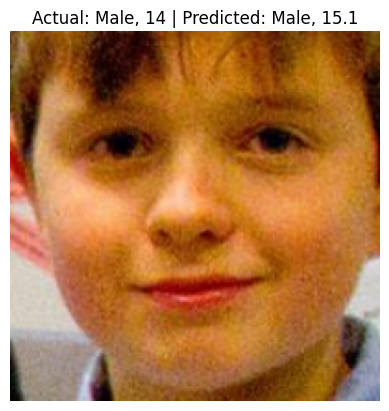

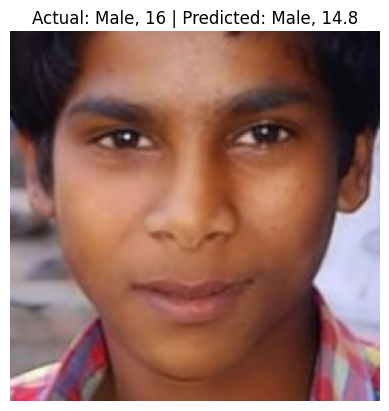

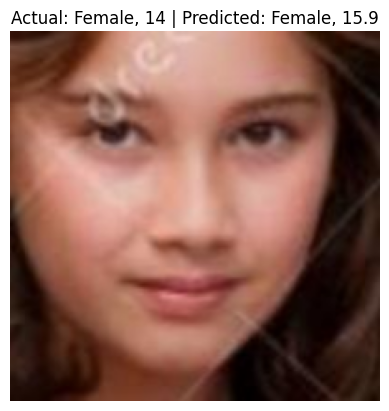

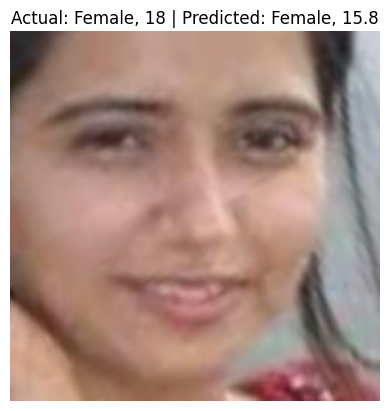

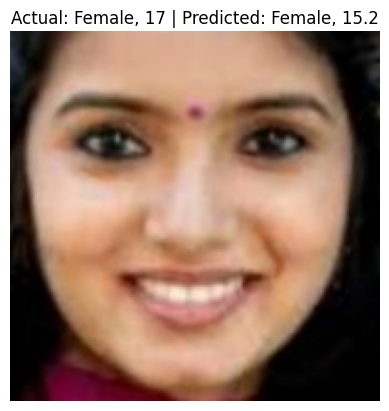

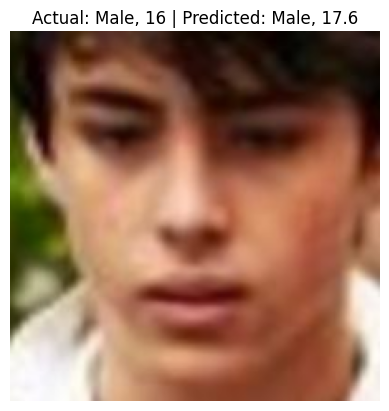

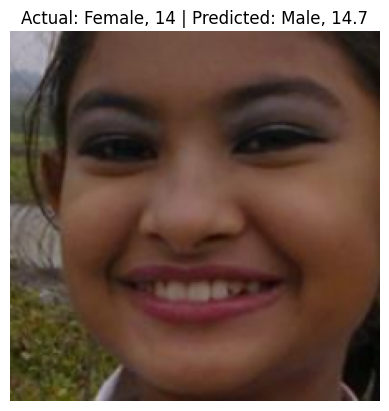

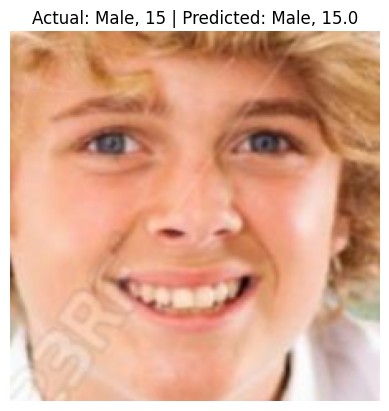

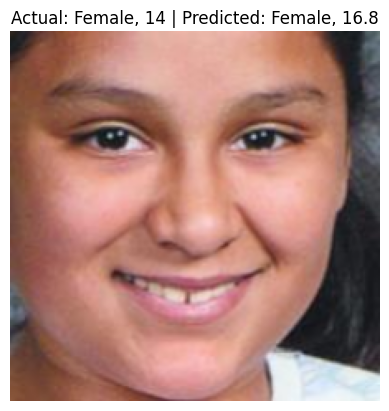

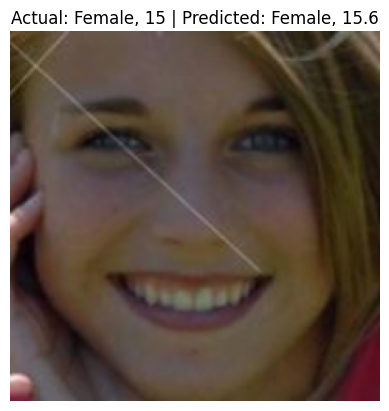

In [43]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load trained model
model = load_model("best_model.h5")

DATASET_PATH = "utkface_aligned_cropped/crop_part1"
IMAGE_SIZE = 224


def parse_filename(filename):
    parts = filename.split("_")
    age = int(parts[0])
    gender = int(parts[1])
    return age, gender


def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))

    img_array = np.array(img, dtype=np.float32)
    img_array = preprocess_input(img_array)

    img_array = np.expand_dims(img_array, axis=0)

    return img, img_array


# Collect all teen images
teen_files = []

for file in os.listdir(DATASET_PATH):

    if not file.endswith(".jpg"):
        continue

    age, gender = parse_filename(file)

    if 13 <= age <= 19:
        teen_files.append(file)

print("Total teen images found:", len(teen_files))


# Randomly select 10 images
sample_files = random.sample(teen_files, min(10, len(teen_files)))


# Run predictions
for file in sample_files:

    age, gender = parse_filename(file)
    path = os.path.join(DATASET_PATH, file)

    original_img, processed_img = preprocess_image(path)

    gender_pred, age_pred = model.predict(processed_img, verbose=0)

    pred_gender = "Male" if np.argmax(gender_pred) == 0 else "Female"
    pred_age = age_pred[0][0] * 6 + 13

    actual_gender = "Male" if gender == 0 else "Female"

    plt.imshow(original_img)
    plt.title(f"Actual: {actual_gender}, {age} | Predicted: {pred_gender}, {pred_age:.1f}")
    plt.axis("off")
    plt.show()

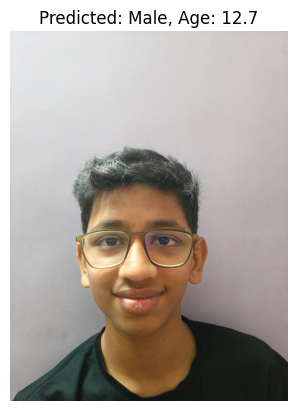

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load trained model
model = load_model("best_model.h5")

IMAGE_SIZE = 224

# Image path
image_path = r"C:\Users\Asus\Documents\Research Project\WhatsApp Image 2026-03-11 at 2.47.56 PM.jpeg"

# Read image
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize to model input
img_resized = cv2.resize(img_rgb, (IMAGE_SIZE, IMAGE_SIZE))

# Preprocess
img_array = np.array(img_resized, dtype=np.float32)
img_array = preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

# Predict
gender_pred, age_pred = model.predict(img_array, verbose=0)

pred_gender = "Male" if np.argmax(gender_pred) == 0 else "Female"
pred_age = age_pred[0][0] * 6 + 13

# Show result
plt.imshow(img_rgb)
plt.title(f"Predicted: {pred_gender}, Age: {pred_age:.1f}")
plt.axis("off")
plt.show()

Gender Classification Accuracy During Training

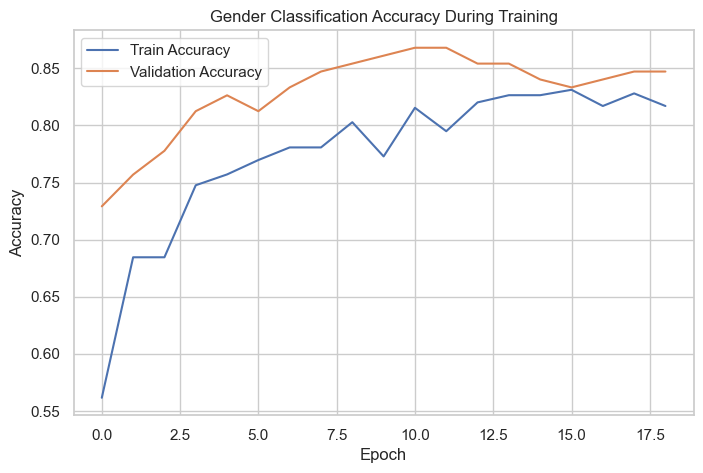

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(8,5))

plt.plot(history1.history['gender_accuracy'], label="Train Accuracy")
plt.plot(history1.history['val_gender_accuracy'], label="Validation Accuracy")

plt.title("Gender Classification Accuracy During Training")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Training vs Validation Loss 

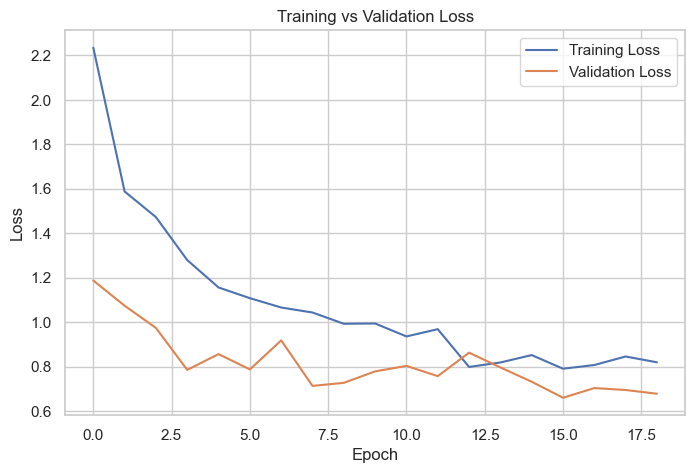

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history1.history['loss'], label="Training Loss")
plt.plot(history1.history['val_loss'], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [26]:
# ...existing code...
import numpy as np

# 1) True labels from val_ds
true_ages_norm = []
true_genders = []

for _, labels in val_ds:
    true_ages_norm.append(labels["age"].numpy().reshape(-1))
    true_genders.append(labels["gender"].numpy().reshape(-1))

true_ages_norm = np.concatenate(true_ages_norm)
true_genders = np.concatenate(true_genders)

# convert age back to years (because training labels were normalized)
true_age = true_ages_norm * 6 + 13
true_gender = true_genders

# 2) Predictions from model on val_ds
pred_gender_prob, pred_age_norm = model.predict(val_ds, verbose=1)

predicted_gender = np.argmax(pred_gender_prob, axis=1)
predicted_age = pred_age_norm.reshape(-1) * 6 + 13

print("true_age:", true_age.shape, "predicted_age:", predicted_age.shape)
print("true_gender:", true_gender.shape, "predicted_gender:", predicted_gender.shape)
# ...existing code...

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step
true_age: (144,) predicted_age: (144,)
true_gender: (144,) predicted_gender: (144,)


Gender Prediction Confidence Distribution

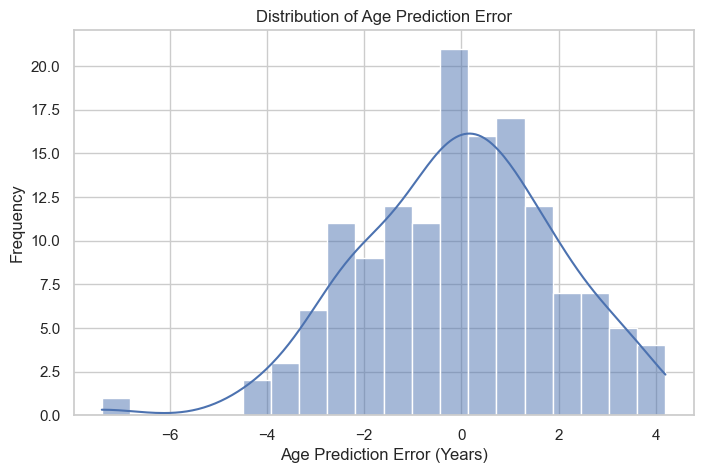

In [27]:
import numpy as np
import seaborn as sns

age_errors = np.array(true_age) - np.array(predicted_age)

plt.figure(figsize=(8,5))

sns.histplot(age_errors, bins=20, kde=True)

plt.title("Distribution of Age Prediction Error")
plt.xlabel("Age Prediction Error (Years)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(true_gender, predicted_gender, target_names=["Male","Female"]))

              precision    recall  f1-score   support

        Male       0.88      0.93      0.90        61
      Female       0.95      0.90      0.93        83

    accuracy                           0.92       144
   macro avg       0.91      0.92      0.92       144
weighted avg       0.92      0.92      0.92       144



Gender Prediction Confidence Distribution

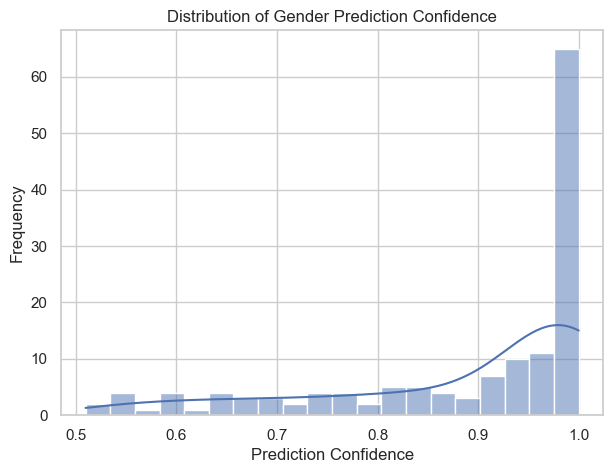

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

gender_probabilities = []

# Run predictions on validation dataset
for images, labels in val_ds:
    
    gender_pred, age_pred = model.predict(images, verbose=0)
    
    # store probabilities
    gender_probabilities.extend(gender_pred)

# Convert to numpy array
gender_probabilities = np.array(gender_probabilities)

# Confidence = highest probability (softmax output)
confidence_scores = np.max(gender_probabilities, axis=1)

plt.figure(figsize=(7,5))

sns.histplot(confidence_scores, bins=20, kde=True)

plt.title("Distribution of Gender Prediction Confidence")
plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")

plt.show()